# PHYS-467 Machine Learning for Physisicst
Custering - Solutions

*1. Generate K Gaussian clusters of $n$ samples. Each cluster has $n_k = n/K$ data points $\boldsymbol{x}^{\mu}_{i,k} \in \mathbb{R}^{d}$ of mean  $\mu_k \in \mathbb{R}^{d}$, and covariance matrix  $\Sigma = \sigma \mathbb{I}_{d\times d}$. Take $d = 2$. Plot the data points in the 2-dimensional space with their centroids and assign to each data point a color according to cluster membership.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import random

In [ ]:
def get_data(m, sigma, nk, d, K):
  """
  This function generates Gaussian clusters.
  Input:  m = center coordinate of each cluster;
          sigma = variance of each cluster;
          nk = number of samples in each cluster;
          d = input dimension;
          K = number of clusters.
  Output: X = data, with shape (K*nk,d), organized in K clusters
  """
  X = np.concatenate([np.random.normal(m[k], sigma, size = (nk, d)) for k in range(K)]) # generate K cluster distributed according to the Gaussian distribution
  np.random.shuffle(X) # shuffle the dataset
  return X

In [ ]:
nk = 100
d = 2
K = 3
sigma = 1
m = [[0., 0.], [-5., -10.], [-8., 3.]]

X = get_data(m, sigma, nk, d, K) # build the data

In [ ]:
def distance_from_the_center(X, m):
  """
  This function assign to each example in X a label according to its distance from the center.
  Input:  X = data;
          m = centroids.
  Output: cluster_membership = array of length #of samples, containing the label reffering to the cluster to which examples in X belongs to;
          cost = sum of the square distances of each data point from its cluster 
  """
  cluster_membership = np.zeros(len(X)) # initialize an empty array of length = number of samples
  cost = 0. # initialize the cost function
  for mu in range(len(X)): # loop over all examples
    distances = np.zeros(K) # initialize an empty array of length = input dimension where to store all the distances a given example has from each centroid
    for k in range(K): # loop over all the clusters
      dist = np.linalg.norm(X[mu] - m[k]) # compute the square distance of an example mu from centroid k 
      distances[k] = dist # store the corresponding result in the array of distances
    cluster_membership[mu] = np.argmin(distances) # assign to the example a label referring to the closest cluster 
    cost += np.min(distances**2) # compute the cost function
  return cluster_membership, cost 
  

In [ ]:
cluster_membership, cost = distance_from_the_center(X, m) # extract the label of each example according to the cluster to which it belongs

In [ ]:
def plot_clusters_and_centroids(X, m, cluster_membership):
  """
  This function plots each cluster and its corresponding centroid.
  Input: X = data points;
         m =  centroids;
         cluster_membership = array of length #of samples, containing the label referring to the cluster to which examples in X belongs to. 
  Output: plot of the clusters and their centroids. Use a different color for each cluster, and black for the centroids
  """
  plt.scatter(X[:,0], X[:,1], c = cluster_membership, cmap=matplotlib.colors.ListedColormap(["green", "red", "lightblue"])) # plot the data points
  plt.scatter(m[0][0], m[0][1], c = 'black', marker = 'o') # plot the centroids
  plt.scatter(m[1][0], m[1][1], c = 'black', marker = 'o')
  plt.scatter(m[2][0], m[2][1], c = 'black', marker = 'o')
  plt.show()
  return

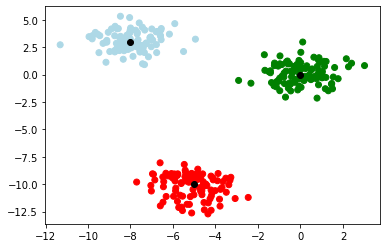

In [ ]:
plot_clusters_and_centroids(X, m, cluster_membership)

*2. Implement K-Means from scratch. At each iteration of the algorithm, compute the cost function and plot the detected clusters with their centroids and colors assigned according to cluster membership. Plot the cost function as a function of the number of iterations.*

In [ ]:
import pandas as pd

In [ ]:
def compute_new_centroids(X, K, centroids, cluster_membership):
  """
  This function compute the centroids as the mean of the input datapoints according to their cluster membership.
  Input: X = data points;
         K = number of clusters;
         centroids = current centroids.
         cluster_memebership = array of length #of samples, containing the label referring to the cluster to which examples in X belongs to.
  Output: centroids.

  """
  for k in range(K): # loop over the number of clusters
      itemindex = np.argwhere(cluster_membership == k).flatten() # for each datapoint select all the data points belonging to cluster k
      centroids[k] = np.mean(X[itemindex], axis = 0) # compute the centroids as the mean of all the points belonging to cluster k
  return centroids

In [ ]:
def k_means(X, max_iters, thr, n_iter_no_change):
  """
  This function implements the K-Means algorithm.
  Input:  X = data points;
          max_iters = number of iterations;
          thr = threshold for convergence and used as a stopping criterium (i.e. when centroids move less that thr then we say that in the iterations they did not change);
          n_iter_no_change = number of iteration of the algorithm for which the cost function does not change anymore.
  Output: centroids = centers of the detected clusters;
          cluster_memebership = array of length #of samples, containing the label reffering to the cluster to which examples in X belongs to. 
          res = evolution of the cost function over the number of iterations
  """
  n = len(X)
  # initialize the centroids by chosing them as one of the centroids
  idx = [random.randint(0, n) for k in range(K)] # chose K input data points at random
  centroids = [X[idx[k]] for k in range(K) ] # initialize the centroids according to the selected data points

  res = {'iter': [], 'cost': []} # initialize an empty dictionary where to store the results
  counter = 0 # initialize a counter
  for it in range(max_iters):
    print('it = ', it)
    old_centroids = np.copy(centroids) # make a copy of the actual centroids
    cluster_membership, cost = distance_from_the_center(X, centroids) # extract the labels and the cost function
    plot_clusters_and_centroids(X, centroids, cluster_membership)  # plot how the clusters looks like at current iteration
    res['iter'].append(it) # populate the dictionary of results
    res['cost'].append(cost)
    centroids = compute_new_centroids(X, K, centroids, cluster_membership) # compute the centroids 
    
    if np.mean(np.abs(centroids - old_centroids)) <= thr: # check whether the centroids are changing or not      
      counter += 1
      if  counter > n_iter_no_change:
        break

  res = pd.DataFrame.from_dict(res)
  res.to_csv("./cost_function_over_iters.csv", mode = 'w', index = False) # store the evolution of the cost function accross the algorithm iterations
  return centroids, cluster_membership

it =  0


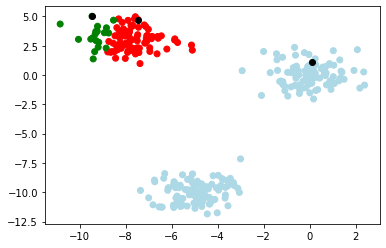

it =  1


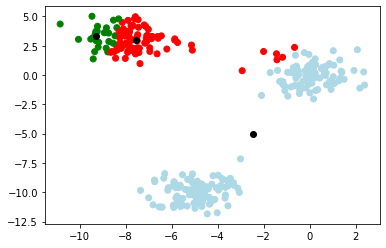

it =  2


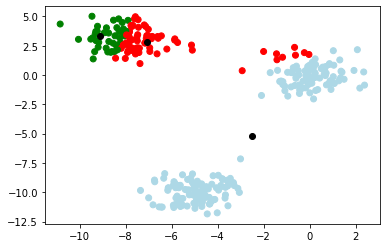

it =  3


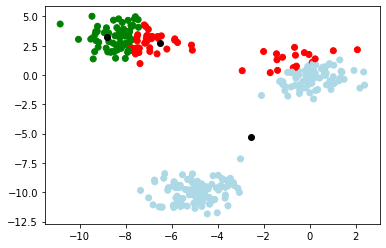

it =  4


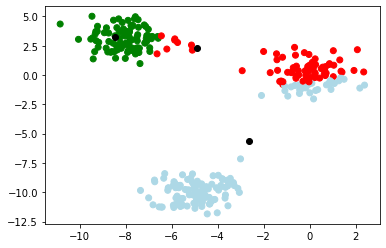

it =  5


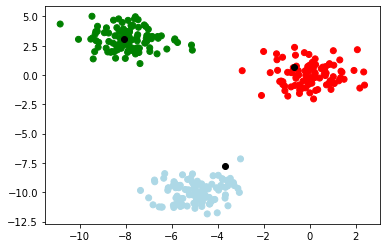

it =  6


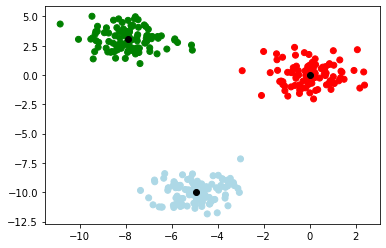

it =  7


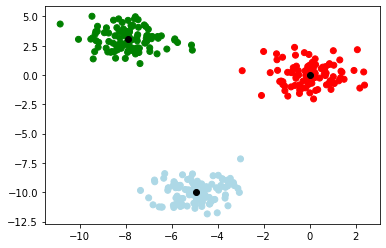

it =  8


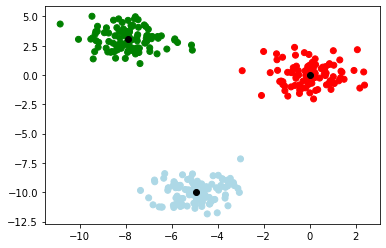

it =  9


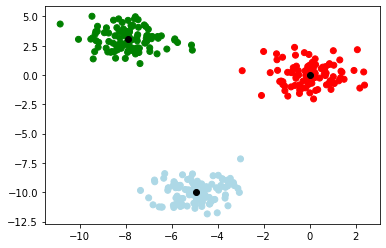

it =  10


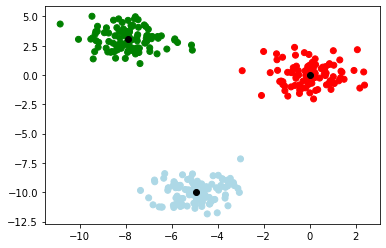

it =  11


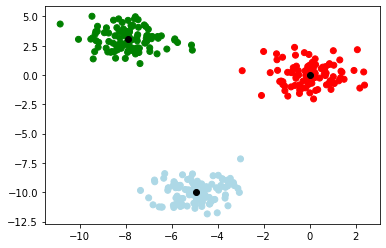

In [ ]:
# run K-Means

max_iters = 100
thr = 1e-8
n_iter_no_change = 5

centroids, cluster_membership = k_means(X, max_iters, thr, n_iter_no_change)

(-1.0, 10.0)

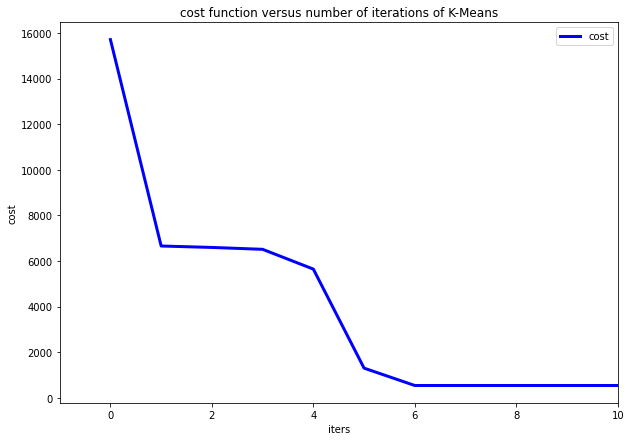

In [ ]:
# plot the cost function 

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./cost_function_over_iters.csv") # read the content of the *.csv file

res.plot(x='iter',
         y='cost',
         color = 'blue',
         lw = 3, # linewidth
         ax=ax) # plot the results with matplotlib through pandas

ax.set_title("cost function versus number of iterations of K-Means") # set the plot title
ax.set_ylabel("cost") # set the name of the y axis
ax.set_xlabel("iters") # set the name of the x axis
ax.set_xlim(-1, 10)

*3. Implement K-Means using the built-in methods from scikit-learn. Compare the implementation from scratch with scikit-learn.*

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# run K-Means from scikit-learn

Kmeans = KMeans(n_clusters=3, init='k-means++') # initialize Kmeans
Kmeans.fit(X) # fit the data with K-Means

KMeans(n_clusters=3)

In [ ]:
centroids = Kmeans.cluster_centers_ # extract the mean
cluster_membership = Kmeans.labels_ # extract the variances

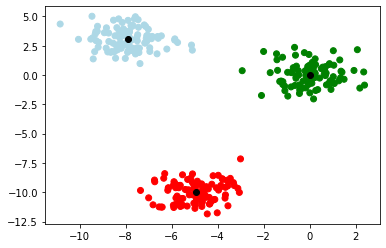

In [ ]:
plot_clusters_and_centroids(X, centroids, cluster_membership)

*4. Vary the variance $\sigma$ of each cluster (i.e. generate several dataset with increasing varince of the clusters) and plot the detected cluster again with their centroids and colors assigned according to cluster membership. What happens to the distance between the centroids found by k-means and the true centroids (the ones used to generate the data) when the variance increases?*

sigma =  0.1


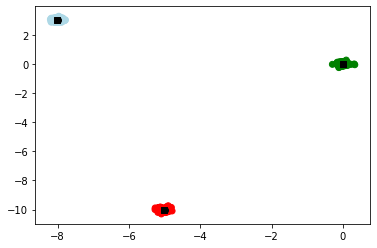

sigma =  0.5


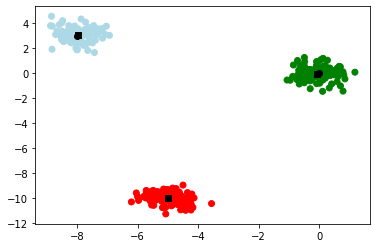

sigma =  1.0


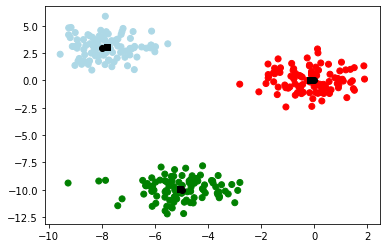

sigma =  5.0


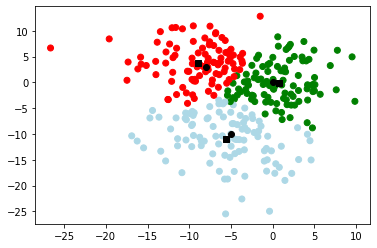

sigma =  10.0


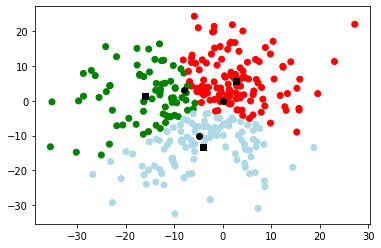

sigma =  100.0


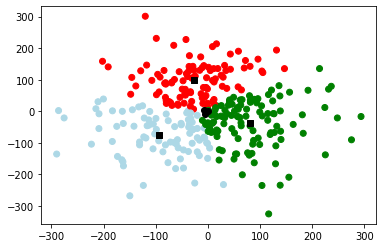

In [ ]:
sigmas = [0.1, 0.5, 1., 5., 10., 100.]

for sigma in sigmas:
  print("sigma = ", sigma)
  X = get_data(m, sigma, nk, d, K) # get the data
  Kmean = KMeans(n_clusters=3, init='k-means++') # run K-Means
  Kmean.fit(X)
  centroids = Kmean.cluster_centers_ # extract the means and the labels
  cluster_membership = Kmean.labels_
  plt.scatter(X[:,0], X[:,1], c = cluster_membership, cmap=matplotlib.colors.ListedColormap(["green", "red", "lightblue"])) # plot how the cluster prediction evolves according to noise
  plt.scatter(centroids[0][0], centroids[0][1], c = 'black', marker = 's') 
  plt.scatter(centroids[1][0], centroids[1][1], c = 'black', marker = 's')
  plt.scatter(centroids[2][0], centroids[2][1], c = 'black', marker = 's')
  plt.scatter(m[0][0], m[0][1], c = 'black', marker = 'o') 
  plt.scatter(m[1][0], m[1][1], c = 'black', marker = 'o')
  plt.scatter(m[2][0], m[2][1], c = 'black', marker = 'o')
  plt.show()

